In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
path = "/content/gdrive/MyDrive/Colab Notebooks/"
import sys; sys.path.append(path+'lib')
from variable_print import p,ps,pst

# TD Actor-critic Algorithm 구현

In [3]:
import tensorflow as tf
import tensorflow_probability as tfp
import keras
from keras.layers import Dense,Input
from keras.models import Sequential
from keras.optimizers import Adam

import sys
import pylab
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Environment : CartPole 생성

In [4]:
import gymnasium as gym
env = gym.make("CartPole-v1", render_mode="rgb_array")
print(gym.__version__)  #1.2.0
print("="*10)
print('State space: ', env.observation_space)
print('Action space: ', env.action_space)
print("="*10)
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
print(f"State dimension: {state_size}")
print(f"Action dimension: {action_size}")
value_size = 1

1.2.0
State space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:  Discrete(2)
State dimension: 4
Action dimension: 2


## Actor, Critic Network 만들기  

In [5]:
actor_lr = 0.01
critic_lr = 0.01

# actor network : output= prob(action)
def build_actor():
    actor = Sequential()
    actor.add(Input(shape=(state_size,)))
    actor.add(Dense(30, activation='relu', kernel_initializer='he_uniform'))
    actor.add(Dense(30, activation='relu', kernel_initializer='he_uniform'))
    actor.add(Dense(action_size, activation='softmax',
                    kernel_initializer='he_uniform'))
    actor.optimizer=Adam(learning_rate=actor_lr)
    return actor

# critic: state is input and value of state is output of model
def build_critic():
    critic = Sequential()
    critic.add(Input(shape=(state_size,)))
    critic.add(Dense(30, activation='relu', kernel_initializer='he_uniform'))
    critic.add(Dense(30, activation='relu', kernel_initializer='he_uniform'))
    critic.add(Dense(value_size, activation='linear',
                     kernel_initializer='he_uniform'))
    critic.optimizer=Adam(learning_rate=critic_lr)
    return critic

actor = build_actor()
actor.summary()
critic = build_critic()
critic.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            62 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142 (4.46 KB)

 Trainable params: 1,142 (4.46 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 30)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,111 (4.34 KB)

 Trainable params: 1,111 (4.34 KB)

 Non-trainable params: 0 (0.00 B)

## A2C(Advantage Actor-Critic) agent

In [6]:
### A2C(Advantage Actor-Critic) agent for the Cartpole
class A2CAgent:
    def __init__(self, actor, critic):
        self.actor = actor
        self.critic = critic
        self.state_size = state_size
        self.action_size = action_size
        self.value_size = 1
        self.gamma = 0.99
        self._eps = 1e-25


    def get_action(self, state):
        policy = self.actor.predict(state, batch_size=1,verbose=0).flatten()
        return np.random.choice(self.action_size, 1, p=policy)[0]

    # def actor_loss(self,prob_a, action, td_error):
    #     dist = tfp.distributions.Categorical(probs=prob_a, dtype=tf.float32)
    #     log_prob = dist.log_prob(action)    # prob_a=[0.3,0.7], action=1
    #     loss = -log_prob * td_error         # -log(prob_a[action])*td_error
    #     return loss

    def actor_loss(self, prob_a, action, td_error):
        log_probability = tf.math.log(prob_a[0][action] + self._eps)
        loss = -log_probability * td_error
        return loss

    # update policy network every episode
    def train_model(self, state, action, reward, next_state, done):
        with tf.GradientTape() as a_tape, tf.GradientTape() as c_tape:
            value = self.critic(state, training=True)[0]
            next_value = self.critic(next_state, training=True)[0]
            td_target = reward + self.gamma*next_value *(1-done)
            td_error = td_target - value
            c_loss = tf.math.square((value-td_target))
            prob_a = self.actor(state.reshape(1,4), training=True)#두action의 확률
            a_loss = self.actor_loss(prob_a, action, td_error)    #-log(pi()*td_error
            loss = a_loss + c_loss
        c_grads = c_tape.gradient(c_loss, self.critic.trainable_variables)
        a_grads = a_tape.gradient(a_loss, self.actor.trainable_variables)
        self.critic.optimizer.apply_gradients(zip(c_grads,self.critic.trainable_variables))
        self.actor.optimizer.apply_gradients(zip(a_grads,self.actor.trainable_variables))
        return (loss,a_loss,c_loss)

## TD 알고리즘 : step-by-step update  
>Critic 학습 : Temporal-difference 기법을 사용해서 진행  
>에피소드가 끝나기 전에 각각의 transition sample 만으로도 학습을 진행

In [7]:
%%time
# make A2C agent
actor = build_actor()
critic = build_critic()
agent = A2CAgent(actor,critic)

mean_score = 0
print_every = 2
max_steps = 200
scores = []

n_eps = 20 #200 ##########
for ep in range(n_eps):
    score = 0
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    while True:
        action = agent.get_action(state)
        next_state, reward, done, info, _ = env.step(action)
        next_state = np.reshape(next_state, [1, state_size])
        if done and score < max_steps: reward = -100   # 중간에 끝나면 벌점
        losses = agent.train_model(state, action, reward, next_state, done)
        score += reward
        state = next_state
        if done: break
    score = score if score > max_steps else score + 100 # 벌점 보상
    scores.append(score)
    mean_score = np.mean(scores[-min(10,len(scores)):])
    if ep % print_every == 0:
        print(f"Episode {ep} || mean_score: {mean_score:0.1f} ||  Actor_Loss: {losses[1]}, Critic_loss:{losses[2]}")
    if mean_score > 200: break


Episode 0 || mean_score: 10.0 ||  Actor_Loss: [0.], Critic_loss:[7498.5024]
Episode 2 || mean_score: 12.0 ||  Actor_Loss: [-0.26856157], Critic_loss:[5045.2944]
Episode 4 || mean_score: 14.4 ||  Actor_Loss: [-23.07376], Critic_loss:[6246.803]
Episode 6 || mean_score: 21.4 ||  Actor_Loss: [-1.1713299], Critic_loss:[5282.6143]
Episode 8 || mean_score: 31.4 ||  Actor_Loss: [-48.672443], Critic_loss:[2409.4563]
Episode 10 || mean_score: 37.8 ||  Actor_Loss: [-0.7325083], Critic_loss:[189.00859]
Episode 12 || mean_score: 43.0 ||  Actor_Loss: [0.04664331], Critic_loss:[78.04993]
Episode 14 || mean_score: 53.3 ||  Actor_Loss: [0.07752135], Critic_loss:[26.861103]
Episode 16 || mean_score: 64.0 ||  Actor_Loss: [-0.04133265], Critic_loss:[231.52351]
Episode 18 || mean_score: 62.2 ||  Actor_Loss: [-0.00279951], Critic_loss:[4855.8564]
CPU times: user 2min 14s, sys: 3.38 s, total: 2min 17s
Wall time: 2min 16s


In [8]:
%%time
# make A2C agent
actor = build_actor()
critic = build_critic()
agent = A2CAgent(actor,critic)

n_eps = 200
mean_score = 0
print_every = 2
max_steps = 200
scores = []

for ep in range(n_eps):
    score = 0
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    while True:
        action = agent.get_action(state)
        next_state, reward, done, info, _ = env.step(action)
        next_state = np.reshape(next_state, [1, state_size])
        if done and score < max_steps: reward = -100   # 중간에 끝나면 벌점
        losses = agent.train_model(state, action, reward, next_state, done)
        score += reward
        state = next_state
        if done: break
    score = score if score > max_steps else score + 100 # 벌점 보상
    scores.append(score)
    mean_score = np.mean(scores[-min(10,len(scores)):])
    if ep % print_every == 0:
        print(f"Episode {ep} || mean_score: {mean_score:0.1f} ||  Actor_Loss: {losses[1]}, Critic_loss:{losses[2]}")
    if mean_score > 200: break
# Wall time: 17min 12s

Episode 0 || mean_score: 111.0 ||  Actor_Loss: [-0.16617985], Critic_loss:[9530.19]
Episode 2 || mean_score: 73.0 ||  Actor_Loss: [-4.8829784], Critic_loss:[8290.352]
Episode 4 || mean_score: 58.4 ||  Actor_Loss: [-13.857089], Critic_loss:[4440.9487]
Episode 6 || mean_score: 51.0 ||  Actor_Loss: [-0.00291836], Critic_loss:[331.23962]
Episode 8 || mean_score: 46.6 ||  Actor_Loss: [-0.00116842], Critic_loss:[15.596329]
Episode 10 || mean_score: 39.8 ||  Actor_Loss: [0.00038679], Critic_loss:[3.36529]
Episode 12 || mean_score: 37.6 ||  Actor_Loss: [-0.00086149], Critic_loss:[0.10326588]
Episode 14 || mean_score: 43.9 ||  Actor_Loss: [-0.00061927], Critic_loss:[7020.257]
Episode 16 || mean_score: 44.5 ||  Actor_Loss: [-6.239673e-05], Critic_loss:[61.030983]
Episode 18 || mean_score: 49.4 ||  Actor_Loss: [-2.0396095e-05], Critic_loss:[3252.604]
Episode 20 || mean_score: 53.5 ||  Actor_Loss: [4.6338584e-05], Critic_loss:[4.561558]
Episode 22 || mean_score: 54.3 ||  Actor_Loss: [0.00120517], 

Wall time: 14min 34s


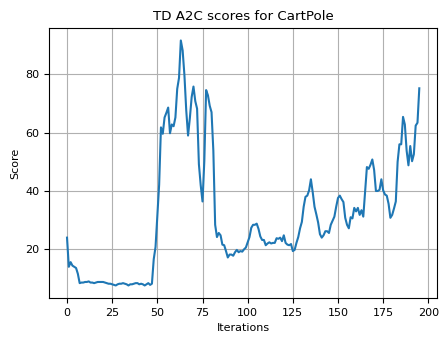

In [ ]:
def plot_moving_avg(data, window_size):
    if not data: return
    moving_avg = np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    plt.plot(moving_avg)

plot_moving_avg(scores,5)
plt.title('TD A2C scores for CartPole')
plt.ylabel('Score')
plt.xlabel('Iterations')
plt.grid()
plt.show()

In [ ]:
# scores_np = np.array(scores)
# def ma(a, n=5):
#     ret = np.cumsum(a, dtype=float)
#     ret[n:] = ret[n:] - ret[:-n]
#     return ret[n - 1:] / n

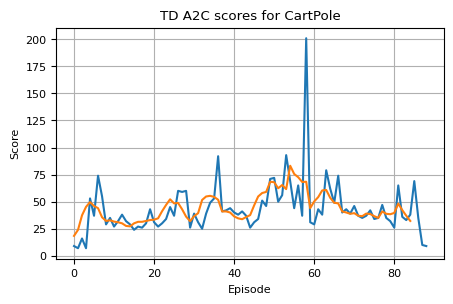

In [ ]:
# plt.figure(figsize=(5,3))
# plt.plot(scores)
# plt.plot(ma(scores_np))
# plt.title('TD A2C scores for CartPole')
# plt.ylabel('Score')
# plt.xlabel('Episode')
# plt.grid()
# plt.show()

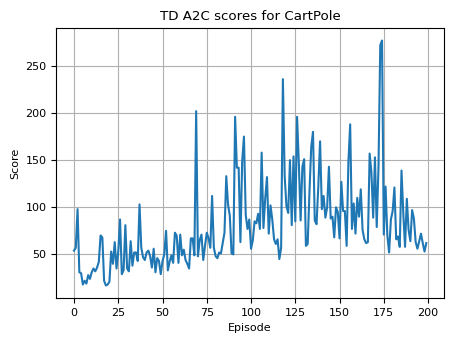

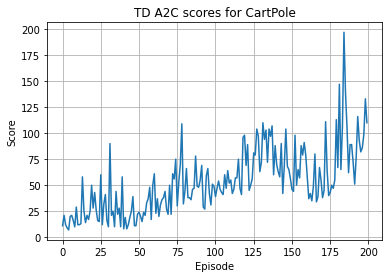

In [ ]:
#actor.save(path+"models/DRL/cartpole_by_A2C.keras")
actor = keras.models.load_model(path+"models/DRL/cartpole_by_A2C.keras")

## Evaluation

In [ ]:
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env_v = wrap_env(env, path=path, name_prefix="A2C")

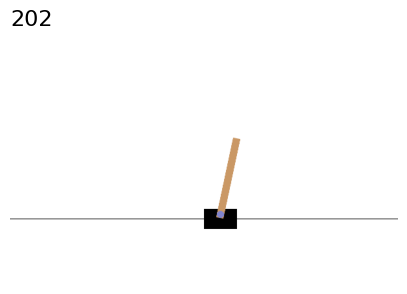

In [ ]:
state, _ = env_v.reset()
cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    predict = actor.predict(state.reshape(1,4),verbose=0)
    action = np.argmax(predict)
    state, reward, done, info, _ = env_v.step(action)
    if done:  break;
    cnt += 1
env_v.close()

In [ ]:
show_video(path=path,name_prefix='A2C')

/content/gdrive/MyDrive/Colab Notebooks/video/A2C-episode-1.mp4


# 실습과제  
## Actor-Critic Network 결합 모델을 만들어 학습 해 보자   


Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 4)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_24 (Dense)          │ (None, 64)             │            320 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_25 (Dense)          │ (None, 64)             │          4,160 │ dense_24[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ actor (Dense)             │ (None, 2)              │            130 │ dense_25[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ critic (Dense)            │ (None, 1)              │             65 │ dense_25[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 4,675 (18.26 KB)

 Trainable params: 4,675 (18.26 KB)

 Non-trainable params: 0 (0.00 B)

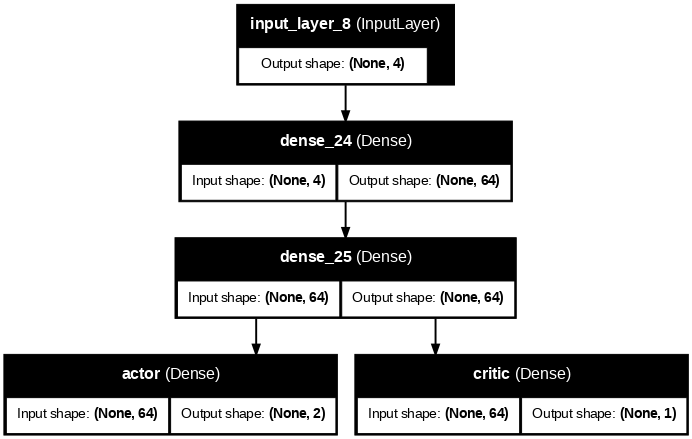

In [ ]:
def ActorCritic(lr=0.01):
    in_layer = keras.Input(shape=(state_size,))
    fc1 = keras.layers.Dense(64, activation="relu",
                             kernel_initializer='he_uniform')(in_layer)
    fc2 = keras.layers.Dense(64, activation="relu")(fc1)

    critic = keras.layers.Dense(1, kernel_initializer='he_uniform',name='critic')(fc2)
    actor = keras.layers.Dense(action_size,activation='softmax',
                               kernel_initializer='he_uniform',name='actor')(fc2)
    actor_critic = keras.Model(inputs=in_layer,outputs=[actor,critic])
    actor_critic.optimizer=Adam(learning_rate=lr,clipnorm=5.0)
    return actor_critic
actor_critic = ActorCritic()
actor_critic.summary()
keras.utils.plot_model(actor_critic,show_shapes=True,show_layer_names=True,dpi=70)

In [ ]:
# A2C(Advantage Actor-Critic) agent for the Cartpole
class A2CAgent:
    def __init__(self, actor_critic):
        # if you want to see Cartpole learning, then change to True
        self.actor_critic = actor_critic
        # get size of state and action
        self.state_size = state_size
        self.action_size = action_size
        self.value_size = 1

        # These are hyper parameters for the Policy Gradient
        self.discount_factor = 0.99
        self.gamma = 0.99

#    def get_action(self, state): ##########

#    def actor_loss(self,prob_a, action, td_error): ##########

    def train_model(self, state, action, reward, next_state, done):
        with tf.GradientTape() as tape:
            _, value = self.actor_critic(state, training=True)

            ### ... ###

            prob_a,_ = self.actor_critic(state.reshape(1,4), training=True)
            a_loss = self.actor_loss(prob_a, action, td_error)

            loss = a_loss + c_loss
        grads = tape.gradient(loss, self.actor_critic.trainable_variables)
        self.actor_critic.optimizer.apply_gradients(zip(grads,\
                                self.actor_critic.trainable_variables))
        return (loss,a_loss,c_loss)

In [ ]:
%%time
# make A2C agent
actor_critic = ActorCritic()
agent = A2CAgent(actor_critic)

n_eps = 200
mean_score = 0
print_every = 2
max_steps = 200
scores, episodes = [], []

for ep in range(n_eps):
    done = False
    score = 0
    state = env.reset()
    state = np.reshape(state, [1, state_size])
    while True:
    ### ... ###
        losses = agent.train_model(state, action, reward, next_state, done)
    ### ... ###
        if done: break
    score = score if score > max_steps else score + 100 # 벌점 보상
    scores.append(score)
    episodes.append(ep)
    mean_score = np.mean(scores[-min(10,len(scores)):])
    if ep % print_every == 0:
        print(f"Episode {ep} || mean_score: {mean_score:0.1f} ||  Actor_Loss: {losses[1]}, Critic_loss:{losses[2]}")
    if mean_score > 200: break


In [ ]:
import matplotlib.pyplot as plt

plt.plot(scores)
plt.title('Shared A2C scores for CartPole')
plt.ylabel('Score')
plt.xlabel('Episode')
plt.grid()
plt.show()

## Evaluation

In [ ]:
%%time
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env_v = wrap_env(env, path=path, name_prefix="A2C2")

In [ ]:
state = env_v.reset()
cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    predict,_ = actor_critic.predict(state.reshape(1,4),verbose=0)
    action = np.argmax(predict)
    state, reward, done, _ = env_v.step(action)
    if done:  break;
    cnt += 1
env_v.close()